NAME :SHARVAN KOTHARU  
ROLL : 01  

SEC : A3  

ML - LAB EXP 01 : PART B  

EDA OF GAME ADDICTION & MENTAL HEALTH ANALYSIS


In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [59]:
df=pd.read_csv('/content/gaming_addiction.csv')

# STEP 1 : EDA

In [60]:
df.head(5)

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


In [61]:
df.shape


(250, 49)

In [62]:
df.describe()

,age,years_gaming,daily_playtime_hours,weekly_play_sessions,late_night_sessions_hours,weekend_playtime_hours,consecutive_hours_max,multiplayer_ratio,toxic_chat_reports,rage_quit_frequency,...,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,addiction_score,addiction_binary,burnout_probability,mental_health_risk_score,churn_probability
count,250.000000,250.000000,250.000000,250.000000,250.0000,250.000000,250.000000,250.000000,250.000000,250.000000,...,250.000000,250.000000,250.00000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,22.160000,9.668000,6.153200,7.056000,2.1024,8.368400,9.714800,0.462240,2.948000,1.896000,...,2.828000,15.986400,5.52400,99.253200,8.239600,38.74448,0.168000,0.996856,0.509640,0.795556
std,5.455037,5.460866,2.656902,3.517721,1.2007,4.085876,4.828877,0.227391,5.451621,2.353581,...,2.088027,10.581607,3.14212,55.057918,2.894558,11.74977,0.374616,0.043240,0.140448,0.120904
min,13.000000,1.000000,0.500000,1.000000,0.0000,0.500000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,5.000000,1.200000,12.28000,0.000000,0.320000,0.120000,0.150000
25%,18.000000,6.000000,4.225000,4.000000,1.1250,5.600000,5.525000,0.300000,0.000000,0.000000,...,1.000000,8.150000,3.00000,61.375000,6.200000,29.88250,0.000000,1.000000,0.406250,0.732250
50%,22.000000,9.000000,6.450000,7.000000,2.1000,8.150000,10.100000,0.450000,1.000000,1.000000,...,3.000000,15.900000,6.00000,99.150000,8.200000,39.87500,0.000000,1.000000,0.515000,0.808000
75%,27.000000,14.750000,8.175000,10.000000,3.0000,10.850000,13.175000,0.630000,2.000000,3.000000,...,4.000000,22.975000,8.00000,133.575000,10.500000,47.11000,0.000000,1.000000,0.600000,0.878000
max,40.000000,25.000000,11.900000,15.000000,5.2000,20.000000,20.600000,1.000000,32.000000,10.000000,...,8.000000,44.200000,14.00000,255.500000,15.100000,68.00000,1.000000,1.000000,0.920000,1.000000


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 49 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      250 non-null    object 
 1   age                          250 non-null    int64  
 2   gender                       250 non-null    object 
 3   country                      250 non-null    object 
 4   occupation                   250 non-null    object 
 5   income_level                 250 non-null    object 
 6   years_gaming                 250 non-null    int64  
 7   preferred_genre              250 non-null    object 
 8   platform                     250 non-null    object 
 9   device_type                  250 non-null    object 
 10  rank_tier                    250 non-null    object 
 11  daily_playtime_hours         250 non-null    float64
 12  weekly_play_sessions         250 non-null    int64  
 13  late_night_sessions_

In [64]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
occupation,0
income_level,0
years_gaming,0
preferred_genre,0
platform,0
device_type,0


### Handling Missing Values

we'll address the missing values in the identified columns. For categorical columns, will impute with the mode, and for numerical columns, will use the median.

In [65]:
# Fill missing values for 'subscription_status' with the mode
if 'subscription_status' in df.columns:
    df['subscription_status'].fillna(df['subscription_status'].mode()[0], inplace=True)

# Fill missing values for 'addiction_severity' with the mode
if 'addiction_severity' in df.columns:
    df['addiction_severity'].fillna(df['addiction_severity'].mode()[0], inplace=True)

# Fill missing values for 'depression_indicator' with the median
if 'depression_indicator' in df.columns:
    df['depression_indicator'].fillna(df['depression_indicator'].median(), inplace=True)

# Fill missing values for 'gpa_or_performance_score' with the median
if 'gpa_or_performance_score' in df.columns:
    df['gpa_or_performance_score'].fillna(df['gpa_or_performance_score'].median(), inplace=True)

# Display null values after imputation to confirm
print("Null values after imputation:")
df.isnull().sum()

Null values after imputation:


/tmp/ipykernel_715/1296973189.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['subscription_status'].fillna(df['subscription_status'].mode()[0], inplace=True)
/tmp/ipykernel_715/1296973189.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].m

,0
user_id,0
age,0
gender,0
country,0
occupation,0
income_level,0
years_gaming,0
preferred_genre,0
platform,0
device_type,0


In [66]:
df.columns[df.isnull().any()]

Index([], dtype='object')

# Check for duplicate values and handle it

In [67]:
df.duplicated().sum() # no duplicates data found

np.int64(0)

In [68]:
df.head()

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


#  Identify outliers & handle it.

### Visualizing Outliers in Numerical Columns



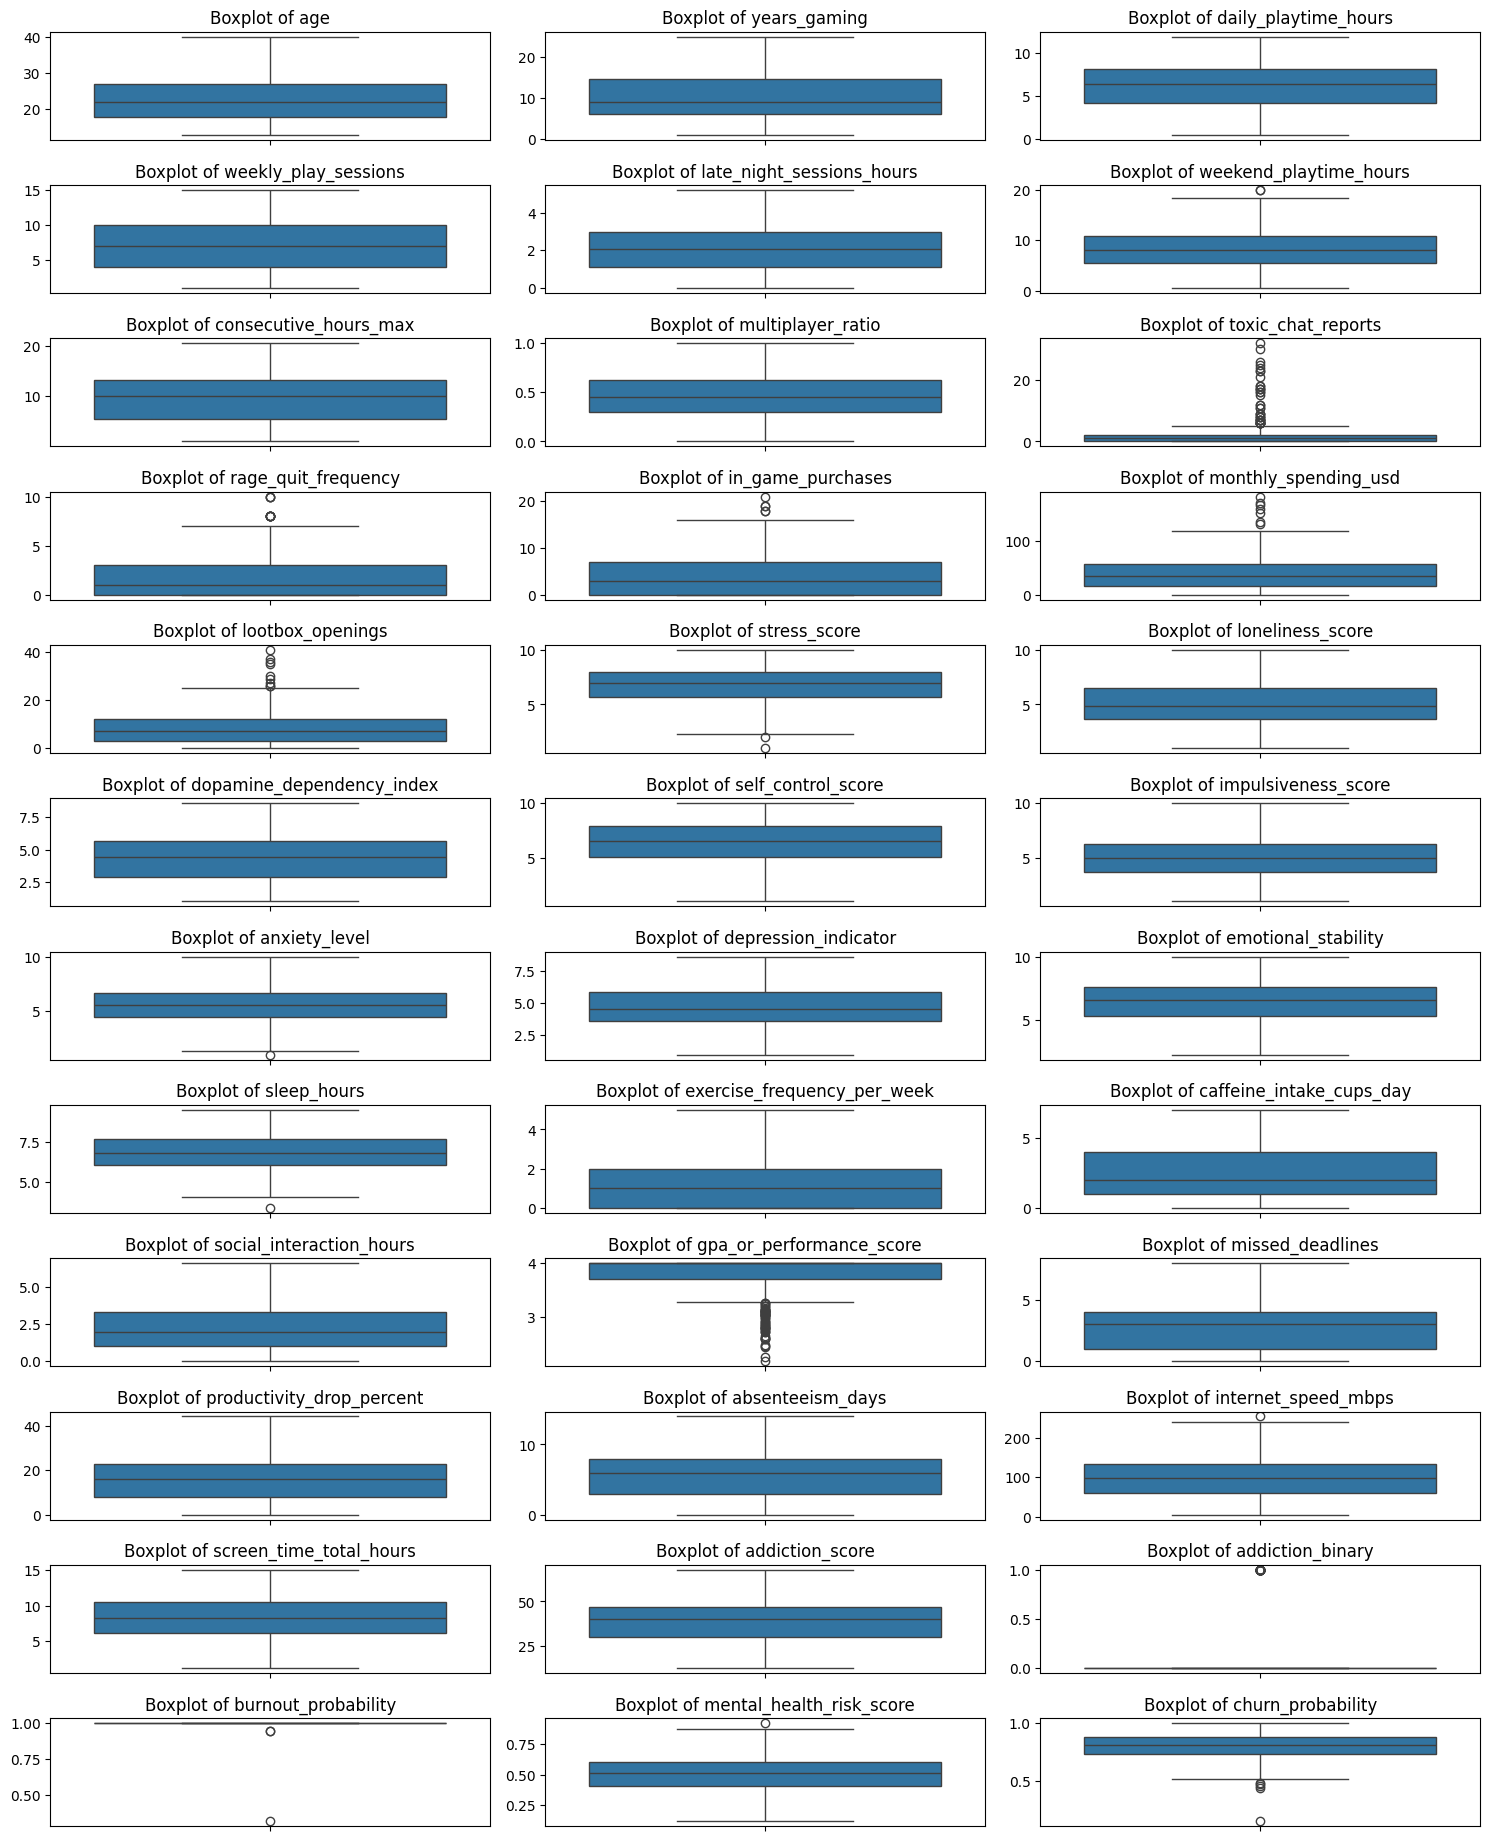

In [69]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [70]:
def detect_outlier(data):
  outlier_list=[]
  data=sorted(data)

  q1=np.percentile(data,25)
  q3=np.percentile(data,75)

  IQR=q3-q1

  lwr_bnd=q1-(1.5*IQR)
  upr_bnd=q3+(1.5*IQR)

  for i in data :
    if (i<lwr_bnd or i>upr_bnd):
       outlier_list.append(i)

  return outlier_list

In [71]:
detect_outlier(df["gpa_or_performance_score"])

[2.17,
 2.25,
 2.43,
 2.45,
 2.47,
 2.59,
 2.59,
 2.6,
 2.6,
 2.64,
 2.71,
 2.72,
 2.73,
 2.77,
 2.78,
 2.8,
 2.8,
 2.81,
 2.81,
 2.83,
 2.84,
 2.86,
 2.86,
 2.9,
 2.9,
 2.92,
 2.95,
 2.97,
 3.0,
 3.01,
 3.03,
 3.03,
 3.04,
 3.04,
 3.05,
 3.05,
 3.07,
 3.08,
 3.08,
 3.08,
 3.09,
 3.1,
 3.1,
 3.12,
 3.12,
 3.13,
 3.14,
 3.16,
 3.2,
 3.21,
 3.24,
 3.25,
 3.26]

  Apply data encoding technique on suitable attribute

In [72]:
df["gender"]=df["gender"].replace("Male",0) #one-hot encoding
df["gender"]=df["gender"].replace("Female",1) #one-hot encoding

In [73]:
df.head()

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,0,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,0,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,0,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,0,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,1,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


# Univariate,Bivariate and multivariate Analysis

<Axes: xlabel='gender', ylabel='count'>

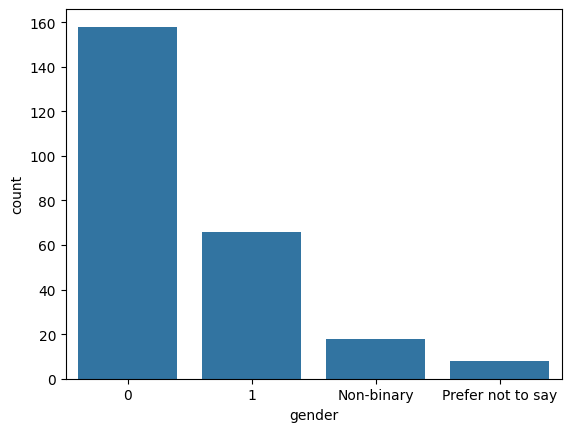

In [74]:
sns.countplot(data=df,x="gender")

<Axes: xlabel='age', ylabel='Count'>

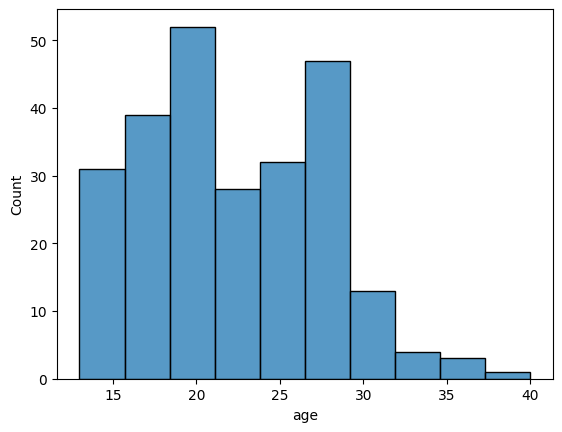

In [76]:
sns.histplot(data=df,x="age")

<Axes: ylabel='count'>

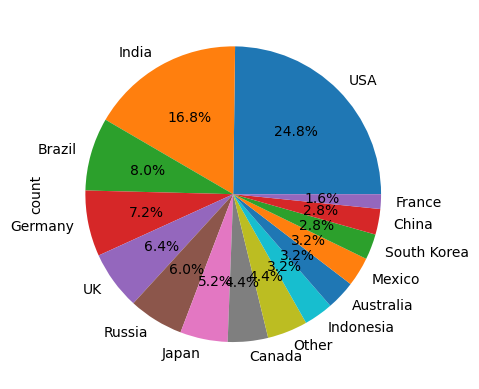

In [77]:
df['country'].value_counts().plot(kind='pie', autopct='%1.1f%%')

<Axes: xlabel='addiction_severity', ylabel='country'>

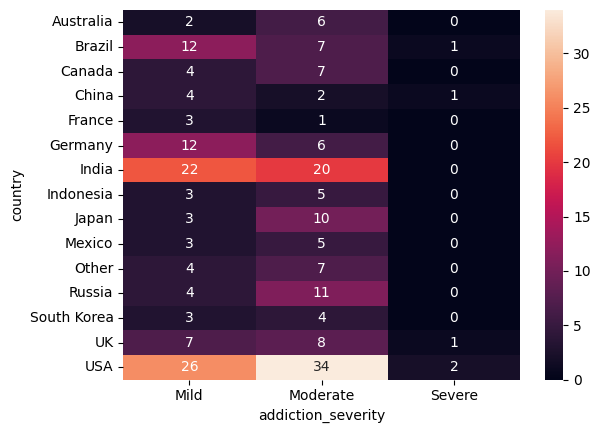

In [97]:
pd.crosstab(df['country'], df['addiction_severity'])

sns.heatmap(pd.crosstab(df['country'], df['addiction_severity']), annot=True)
# india and US have high levels of gaming addiction

<Axes: xlabel='gender', ylabel='count'>

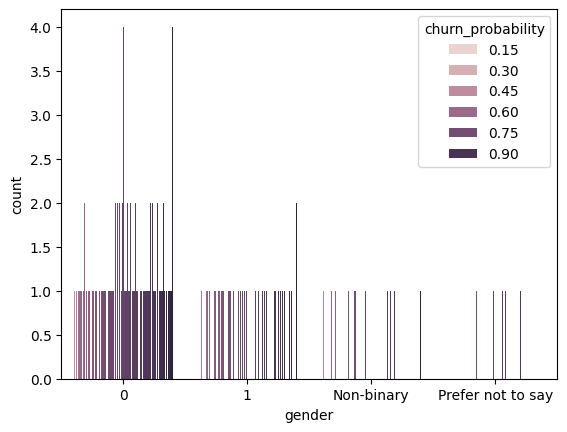

In [95]:
sns.countplot(x='gender', hue='churn_probability', data=df)
# the probability of churn (i.e giving up on game addiction) is higher in males than in females

<Axes: xlabel='age', ylabel='country'>

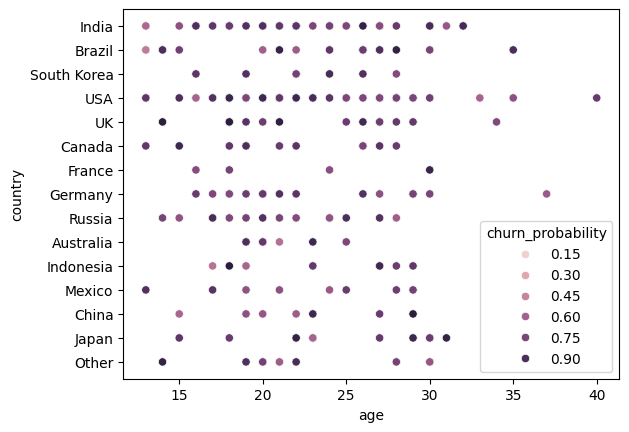

In [101]:
sns.scatterplot(
    x='age',
    y='country',
    hue='churn_probability',
    data=df
) # the probabilty of churn among minors is low overall spc in india

<Axes: xlabel='behavioral_cluster', ylabel='screen_time_total_hours'>

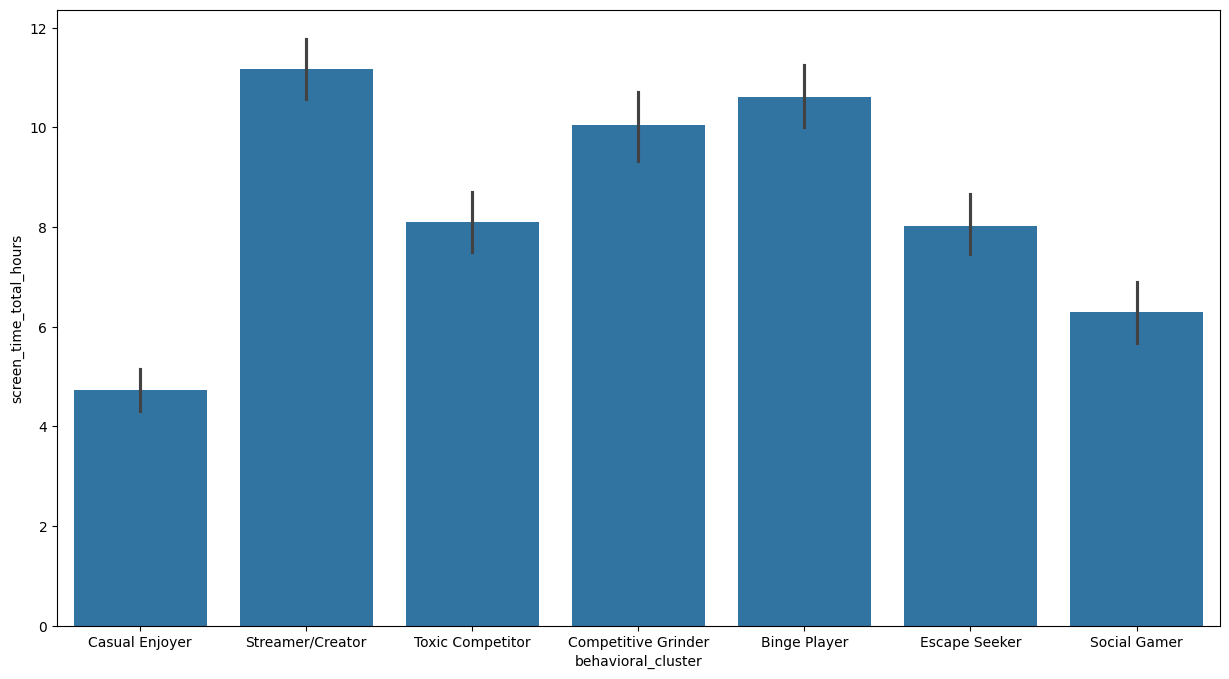

In [115]:
plt.figure(figsize=(15, 8))
sns.barplot(x='behavioral_cluster', y='screen_time_total_hours', data=df)
# streamers have the highest time which is quite obvious

 Apply feature scaling technique on suitable attribute.

In [123]:
from sklearn.preprocessing import StandardScaler

attribute_to_scale = 'age'

scaler = StandardScaler()
df[attribute_to_scale + '_scaled'] = scaler.fit_transform(df[[attribute_to_scale]])

print(f"DataFrame with '{attribute_to_scale}' scaled:")
print(df[[attribute_to_scale, attribute_to_scale + '_scaled']].head())

print(f"\nDescriptive statistics for '{attribute_to_scale}_scaled':")
print(df[attribute_to_scale + '_scaled'].describe())

DataFrame with 'age' scaled:
   age  age_scaled
0   21   -0.213074
1   25    0.521664
2   26    0.705349
3   22   -0.029390
4   17   -0.947812

Descriptive statistics for 'age_scaled':
count    2.500000e+02
mean    -1.421085e-17
std      1.002006e+00
min     -1.682550e+00
25%     -7.641277e-01
50%     -2.938953e-02
75%      8.890332e-01
max      3.276932e+00
Name: age_scaled, dtype: float64


## Data Splitting (Train-Test Split)

In [124]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('addiction_binary', axis=1)  # Drop the target column to get features
y = df['addiction_binary']              # Target column

# Split the data into training and testing sets (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (200, 49)
Shape of X_test: (50, 49)
Shape of y_train: (200,)
Shape of y_test: (50,)
